In [1]:
# # 01 Data Cleaning, EDA, Feature Engineering & Preprocessing
# ## Online Payment Fraud Detection

# %% [code]
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ---------- 1. Load Raw Data ----------
df = pd.read_csv("../data/raw/online_payments_fraud.csv")
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (6362620, 11)

First 5 rows:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
print("\n--- Class Distribution (isFraud) ---")
print(df['isFraud'].value_counts())
print("\n--- Transaction Types ---")
print(df['type'].value_counts())




--- Class Distribution (isFraud) ---
isFraud
0    6354407
1       8213
Name: count, dtype: int64

--- Transaction Types ---
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


In [5]:
df.drop(['nameOrig', 'nameDest'], axis=1, inplace=True)


In [6]:
df['balance_diff_orig'] = df['newbalanceOrig'] - df['oldbalanceOrg']
df['balance_diff_dest'] = df['newbalanceDest'] - df['oldbalanceDest']
df['error_orig'] = abs(df['oldbalanceOrg'] - df['newbalanceOrig'] - df['amount'])
df['error_dest'] = abs(df['oldbalanceDest'] - df['newbalanceDest'] - df['amount'])
df['amount_to_orig_ratio'] = df['amount'] / (df['oldbalanceOrg'] + 1)

In [7]:
df.drop(['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest'], axis=1, inplace=True)

print("Columns after feature engineering:\n", df.columns.tolist())

Columns after feature engineering:
 ['step', 'type', 'amount', 'isFraud', 'isFlaggedFraud', 'balance_diff_orig', 'balance_diff_dest', 'error_orig', 'error_dest', 'amount_to_orig_ratio']


In [8]:
# ---------- 5. One-Hot Encode 'type' ----------
df = pd.get_dummies(df, columns=['type'], prefix='type')
print("Shape after one-hot encoding:", df.shape)

# %% [code]
# ---------- 6. Separate X and y ----------
X = df.drop('isFraud', axis=1)
y = df['isFraud']

# Save feature names for later interpretation
feature_names = X.columns.tolist()
with open("../data/processed/feature_names.txt", "w") as f:
    for feat in feature_names:
        f.write(f"{feat}\n")
print("Feature names saved.")

Shape after one-hot encoding: (6362620, 14)
Feature names saved.


In [9]:
# ---------- 7. Train/Test Split (stratified, 80/20) ----------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

Training set: (5090096, 13), Test set: (1272524, 13)


In [10]:
# ---------- 8. Scale Features ----------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
joblib.dump(scaler, "../models/scaler.pkl")
print("Scaler saved to ../models/scaler.pkl")

Scaler saved to ../models/scaler.pkl


In [11]:
# ---------- 9. Apply SMOTE only on Training Set ----------
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", pd.Series(y_train_balanced).value_counts())


Before SMOTE:
 isFraud
0    5083526
1       6570
Name: count, dtype: int64

After SMOTE:
 isFraud
0    5083526
1    5083526
Name: count, dtype: int64


In [12]:
# ---------- 10. Save Processed Data as .npy Files ----------
np.save("../data/processed/X_train_balanced.npy", X_train_balanced)
np.save("../data/processed/y_train_balanced.npy", y_train_balanced)
np.save("../data/processed/X_test_scaled.npy", X_test_scaled)
np.save("../data/processed/y_test.npy", y_test)
print("✅ Processed data saved successfully!")

✅ Processed data saved successfully!


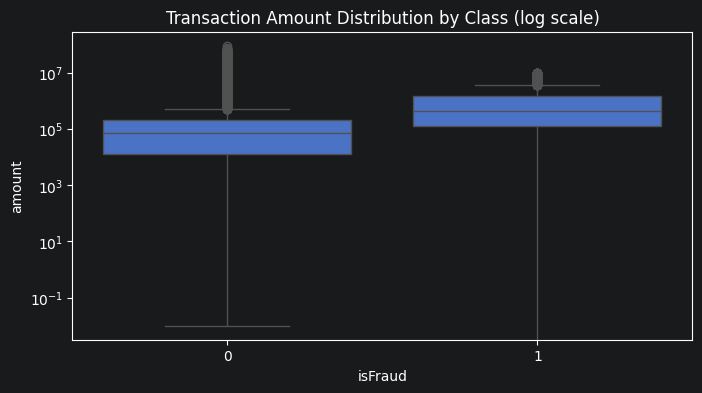

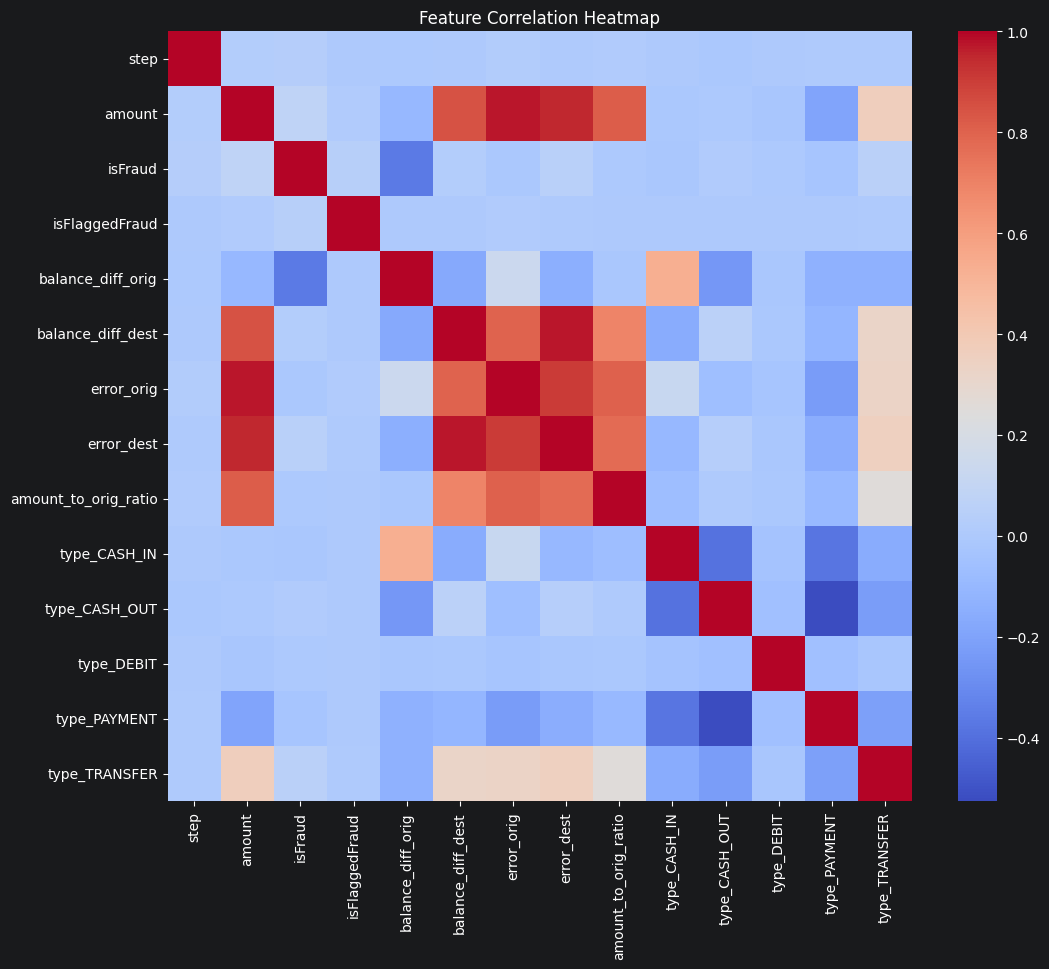

In [13]:
# ---------- 11. Additional EDA Plots (syllabus optional but encouraged) ----------
# Boxplot of amount by class
plt.figure(figsize=(8,4))
sns.boxplot(x='isFraud', y='amount', data=df)
plt.yscale('log')
plt.title('Transaction Amount Distribution by Class (log scale)')
plt.savefig("../data/processed/amount_boxplot.png")
plt.show()

# Correlation heatmap (sample)
plt.figure(figsize=(12,10))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.savefig("../data/processed/correlation_heatmap.png")
plt.show()